In [1]:
import numpy as np
import pandas as pd
from pylab import *
import seaborn as sns
import pickle
import matplotlib.pyplot as plt
import pandas as pd
from pylab import *
from sequana import FastA
import tensorflow as tf
from tensorflow.keras import layers, models
from tqdm import tqdm
from sklearn.model_selection import train_test_split

import random
from collections import defaultdict
from sklearn.metrics import classification_report


2025-08-11 09:53:59.557291: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-11 09:53:59.565805: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-11 09:53:59.613126: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754898839.647141   11968 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754898839.666424   11968 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1754898839.684803   11968 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [2]:
def one_hot_encoding(x):
    if x == 'A':
        return np.array([1,0,0,0], dtype=np.uint8)
    elif x == 'C':
        return np.array([0,1,0,0], dtype=np.uint8)
    elif x == 'G':
        return np.array([0,0,1,0], dtype=np.uint8)
    elif x == 'T':
        return np.array([0,0,0,1], dtype=np.uint8)
    else:
        return np.array([0,0,0,0], dtype=np.uint8)

In [3]:
SIZE=3000

In [4]:
def get_true_positive(centromeres_,f_,size=3000,fail=[]):
    data = []
    for chrom in range(1,36+1):
        if chrom not in fail:
            start, stop = centromeres_[str(chrom)]
            if f_.names[0] == "1":
                seq = f_.sequences[f_.names.index(str(chrom))]
            else:
                seq = f_.sequences[chrom-1]
    
            if stop-start != 3000:
                stop = start + size
            # flip to get more positives
            data.append([one_hot_encoding(x) for x in seq[start:stop]])
            data.append([one_hot_encoding(x) for x in seq[start:stop][::-1]])
            

    return data


In [5]:
from collections import defaultdict
import random
from tqdm import tqdm

def get_true_negatives(centromeres_, lengths_, f_, N=1000, size=3000, seed=42):
    data = []
    positions = defaultdict(list)
    num_chromosomes = 36

    # Calcul taille totale
    total_length = 0
    chrom_lengths = {}
    oking = 0

    for chrom in range(1, num_chromosomes + 1):

        if f_.names[0] == "1":
            if str(chrom) in lengths_:
                chrom_len = lengths_[str(chrom)]
            else:
                chrom_len = -1
        else:
            if chrom != len(lengths_)+1:
                chrom_len = lengths_[chrom - 1]
            else:
                print(lengths_)

                chrom_len = -1
        if chrom_len == -1:
            continue
        chrom_lengths[chrom] = chrom_len
        total_length += chrom_len

    # Calcul du nombre de séquences proportionnel à la taille
    for chrom, chrom_len in tqdm(chrom_lengths.items()):
        seq_count = int((chrom_len / total_length) * N)
        if seq_count == 0:
            seq_count = 1  # au moins une séquence

        start, stop = centromeres_[str(chrom)]
        tries = 0
        extracted = 0
        max_tries = seq_count * 10  # limite essais

        while extracted < seq_count and tries < max_tries:
            pos = random.randint(1, chrom_len - size)
            if oking == 0:
                print(pos)
                oking = 1 

            if pos > start and pos < stop:
                tries += 1
                continue  # exclure centromère
            positions[chrom].append(pos)
            extracted += 1
            tries += 1
    
    # Extraction des séquences
    testing = [0] * num_chromosomes
    for chrom in tqdm(positions.keys()):
        if f_.names[0] == "1":
            seq = f_.sequences[f_.names.index(str(chrom))]
        else:
            seq = f_.sequences[chrom - 1]

        for pos in positions[chrom]:
            testing[chrom - 1] += 1
            data.append([one_hot_encoding(x) for x in seq[pos:pos + size]])

    #print("Nombre de séquences extraites par chromosome :")
    #for i, count in enumerate(testing, 1):
    #    print(f'{i} : {count}')

    return data


In [25]:

##################################### WARNING #############################################
############################### REMOVE FALSE NEGATIVE (centromeres) #######################

def get_true_negatives(centromeres_,lengths_,f_,N=1000,size=3000,seed=42):
    data = []
    positions = defaultdict(list)

    # get the random combos first
    for i in tqdm(range(N)):
        chrom = random.randint(1,36)
        if f_.names[0] == "1":
            if str(chrom) in lengths:
                N = lengths_[str(chrom)]
            else:
                N = -1
        else:
            if str(chrom) != len(lengths_):
                print(chrom-1)
                N = lengths_[chrom-1]
            else:
                N = -1
        if N != -1:
            pos = random.randint(1, N-size)
            start, stop = centromeres_[str(chrom)]
            if pos>start and pos<stop:
                pass # this is a centromeres_ so not a negative
            else:
                positions[chrom].append(pos)
            if i == 0:
                print(chrom)
                print(pos)
                print("########")
            
    testing = [0]*36
    for chrom in tqdm(positions.keys()):
        if f_.names[0] == "1":
            seq = f_.sequences[f_.names.index(str(chrom))]
        else:
            seq = f_.sequences[chrom-1]
        for position in positions[chrom]:
            testing[chrom-1] =  testing[chrom-1] +1
            data.append([one_hot_encoding(x) for x in seq[position:position+size]])
    print("Attention ###########################################################################")
    print("Attention ###########################################################################")
    print("Attention ###########################################################################")
    for glob in range(36):
        print(f'{glob+1} : {testing[glob]}')
          
    return data

    #negatives = get_true_negatives(N=10000, size=SIZE)

In [ ]:
###Data
for i in range(1,11):
    print("###############################################################################")
    print(f'{i}/10')
    print("###############################################################################")
 


   
    with open(f"data/{i}_X_pos.pkl", "wb") as f:
        pickle.dump(X_pos, f)
    with open(f"data/{i}_X_neg.pkl", "wb") as f:
        pickle.dump(X_neg, f)
    print('##############################Data       ############################################')


###############################################################################
1/10
###############################################################################
Genome ../../output/estimation/major/Major.csv


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 36/36 [00:00<00:00, 15387.24it/s]


70446


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 36/36 [00:09<00:00,  3.69it/s]


Genome ../../output/estimation/arabica.csv


...

Genome ../../output/estimation/martiniquensis.csv


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 36/36 [00:00<00:00, 16960.01it/s]


122264


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 36/36 [00:09<00:00,  3.77it/s]


##############################Data       ############################################
pos 826
neg 29786


In [8]:


layers_values = [8,16,32,64]
layers_values = [64]

for layer in layers_values:
    for i in range(2,11):
        print("###############################################################################")
        print(f'{i}/10')
        print("###############################################################################")
     
        X_neg = []
        X_pos = []
        datas =     [["../../data/Fasta/TriTrypDB-68_LmajorFriedlin_Genome.fasta","../../output/estimation/major/Major.csv",[]],
                    ["../../data/Fasta/genomes/Larabica/ragtag.scaffold.fasta","../../output/estimation/arabica.csv",[18,29]],
                    ["../../data/Fasta/genomes/Laethiopica/ragtag.scaffold.fasta","../../output/estimation/aethiopica.csv",[1,29]],
                    ["../../data/Fasta/genomes/Ltropica/LtropicaRef_genome.fasta","../../output/estimation/tropica.csv",[8,18]],
                    ["../../data/Fasta/genome.fasta","../../output/estimation/donovani/donovani_genome.csv",[]],
                    ["../../data/Fasta/genomes/Linfantum/TriTrypDB-68_LinfantumJPCM5_Genome.fasta","../../output/estimation/infantum.csv",[]],
                    ["../../data/Fasta/genomes/LamazonensisPH8/ragtag.scaffold.fasta","../../output/estimation/amazonensis.csv",[8,20,29,36]],
                    ["../../data/Fasta/genomes/Lmexicana/ragtag.scaffold.fasta","../../output/estimation/mexicana.csv",[8,20,29,36]],
                    ["../../data/Fasta/genomes/Ltarentolae/ragtag.scaffold.fasta","../../output/estimation/tarentolae.csv",[]],
                    ["../../data/Fasta/genomes/Lbraziliensis/ragtag.scaffold.fasta","../../output/estimation/braziliensis.csv",[20,34]],
                    #["../../data/Fasta/genomes/Lpanamensis/TriTrypDB-68_LpanamensisMHOMPA94PSC1_Genome.fasta","../../output/estimation/panamensis.csv",[11,24,20,33,34,35,36]],
                    ["../../data/Fasta/genomes/Lorientalis/ragtag.scaffold.fasta","../../output/estimation/orientalis.csv",[20,28]],
                    ["../../data/Fasta/genomes/Lmartiniquensis/ragtag.scaffold.fasta","../../output/estimation/martiniquensis.csv",[1]]]
        random.seed(i)
        for data in datas:
            print(f'Genome {data[1]}')
            f = FastA(data[0])
            centromeres = pd.read_csv(data[1])
            centromeres = {
                str(row['Chromosome']): (row['start'], row['end'])
                for _, row in centromeres.iterrows()
            }
    
            X_pos.extend(get_true_positive(centromeres,f,SIZE,data[2]))
            if f.names[0] == "1":
                lengths = f.get_lengths_as_dict()
            else:
                lengths = list(f.get_lengths_as_dict().values())
            X_neg.extend(get_true_negatives(centromeres,lengths,f,N=2500, size=SIZE,seed=i))
    
        
        print('##############################Data       ############################################')
        print(f'pos {len(X_pos)}')
        print(f'neg {len(X_neg)}')


        # Create label arrays
        y_pos = [1] * len(X_pos)
        y_neg = [0] * len(X_neg)
        
        # Combine and shuffle
        X = np.array(X_pos + X_neg)  # shape: (N, 3000, 4)
        y = np.array(y_pos + y_neg)
        
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, stratify=y, random_state=42
        )
    
    
        layer_size=layer
        print(layer_size)
        print(SIZE)
        model = models.Sequential([
            layers.Input(shape=(SIZE, 4)),
            layers.Conv1D(layer_size, kernel_size=15, activation='relu'),
            layers.MaxPooling1D(pool_size=2),
            layers.Conv1D(layer_size*2, kernel_size=10, activation='relu'),
            layers.GlobalMaxPooling1D(),
            layers.Dense(layer_size, activation='relu'),
            layers.Dense(1, activation='sigmoid')  # binary classification
        ])
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        
        seed = 42
    
        tf.random.set_seed(seed)
        
        tf.config.experimental.enable_op_determinism()
        history = model.fit(
            X_train, y_train,
            validation_data=(X_test, y_test),
            epochs=40,
            batch_size=32,
            class_weight={0: 1, 1: len(y_neg)/len(y_pos)},  # handle imbalance
            callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
        )
    
    
        y_pred = model.predict(X_test) > 0.2
        report = classification_report(y_test, y_pred, output_dict=True)
    
        metrics = {
            'f1_score': report['1']['f1-score'],
            'precision': report['1']['precision'],
            'recall': report['1']['recall']
        }
        results.append(metrics)

        with open(f"{layer}_layer_result_patience_all_2.pkl", "wb") as f:
            pickle.dump(results, f)





###############################################################################
2/10
###############################################################################
Genome ../../output/estimation/major/Major.csv


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 36/36 [00:00<00:00, 18074.57it/s]


29650


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 36/36 [00:09<00:00,  3.95it/s]


Genome ../../output/estimation/arabica.csv


...

766/766 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.7553 - loss: 0.8068

2025-08-11 23:08:36.203044: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


766/766 ━━━━━━━━━━━━━━━━━━━━ 222s 289ms/step - accuracy: 0.7554 - loss: 0.8063 - val_accuracy: 0.9948 - val_loss: 0.0179
Epoch 2/40
766/766 ━━━━━━━━━━━━━━━━━━━━ 221s 288ms/step - accuracy: 0.9775 - loss: 0.1109 - val_accuracy: 0.9961 - val_loss: 0.0150
Epoch 3/40
766/766 ━━━━━━━━━━━━━━━━━━━━ 262s 288ms/step - accuracy: 0.9920 - loss: 0.0447 - val_accuracy: 0.9964 - val_loss: 0.0169
Epoch 4/40
766/766 ━━━━━━━━━━━━━━━━━━━━ 269s 297ms/step - accuracy: 0.9873 - loss: 0.0655 - val_accuracy: 0.9948 - val_loss: 0.0161
Epoch 5/40
766/766 ━━━━━━━━━━━━━━━━━━━━ 221s 288ms/step - accuracy: 0.9945 - loss: 0.0297 - val_accuracy: 0.9931 - val_loss: 0.0215
Epoch 6/40
766/766 ━━━━━━━━━━━━━━━━━━━━ 262s 288ms/step - accuracy: 0.9860 - loss: 0.0836 - val_accuracy: 0.9962 - val_loss: 0.0143
Epoch 7/40
766/766 ━━━━━━━━━━━━━━━━━━━━ 221s 289ms/step - accuracy: 0.9940 - loss: 0.0295 - val_accuracy: 0.9941 - val_loss: 0.0188
Epoch 8/40
766/766 ━━━━━━━━━━━━━━━━━━━━ 228s 297ms/step - accuracy: 0.9966 - loss: 0.01

2025-08-11 23:47:57.895834: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


192/192 ━━━━━━━━━━━━━━━━━━━━ 14s 73ms/step


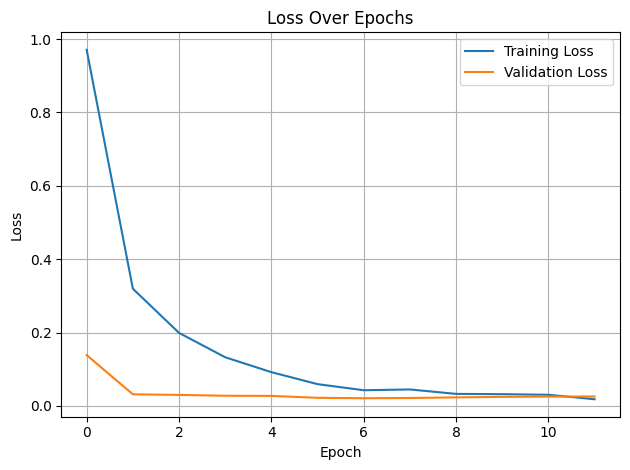

In [20]:
import matplotlib.pyplot as plt


# Plot training & validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


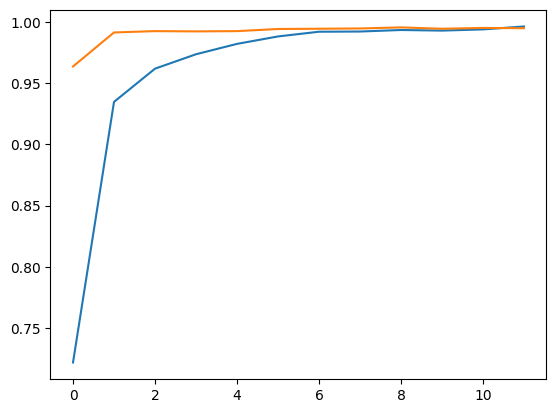

In [21]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')

  9/144 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

2025-07-29 13:18:07.922399: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step


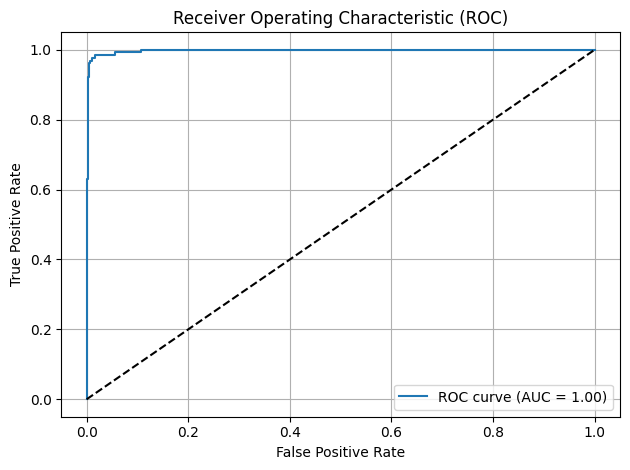

In [22]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities
y_prob = model.predict(X_test).ravel()  # get raw probabilities

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


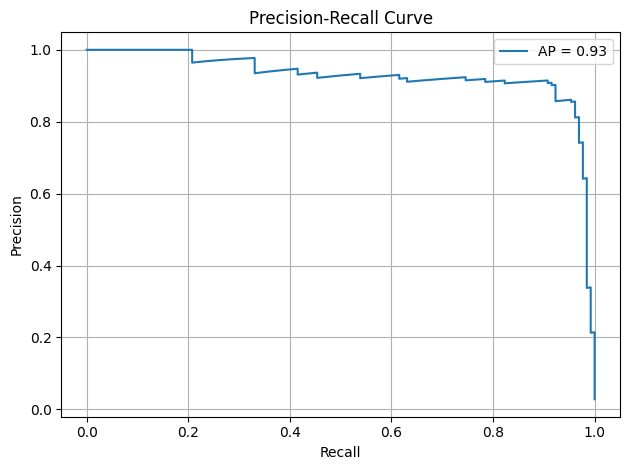

In [23]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_prob)
avg_prec = average_precision_score(y_test, y_prob)

plt.plot(recall, precision, label=f'AP = {avg_prec:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [24]:
import numpy as np

def predict_sliding_windows(seq, model, window_size=3000, step=1500):
    
    scores = []
    positions = []

    # Slide through the sequence
    for i in tqdm(range(0, len(seq) - window_size + 1, step)):
        chunk = seq[i:i + window_size]
        
        # One-hot encoded? Already a list of np.array([1,0,0,0]) per base
        # Otherwise, if string-based: encode here
        chunk = [one_hot_encoding(x) for x in chunk]
        X = np.array(chunk).reshape(1, window_size, 4)  # batch of 1
        prob = model.predict(X, verbose=0)[0][0]
        
        scores.append(prob)
        positions.append((i, i + window_size))

    return positions, scores


In [25]:
all_scores = {}
results = {}


100%|█████████████████████████████████████████| 178/178 [00:13<00:00, 13.19it/s]


1 (256500, 259500) 0.8969919


100%|█████████████████████████████████████████| 236/236 [00:18<00:00, 13.05it/s]


2 (265500, 268500) 0.999775


100%|█████████████████████████████████████████| 255/255 [00:19<00:00, 13.26it/s]


...

34 (298500, 301500) 0.9992364


100%|███████████████████████████████████████| 1392/1392 [01:56<00:00, 11.97it/s]


35 (546000, 549000) 0.9989286


100%|███████████████████████████████████████| 1787/1787 [02:36<00:00, 11.39it/s]

36 (1113000, 1116000) 0.9996134


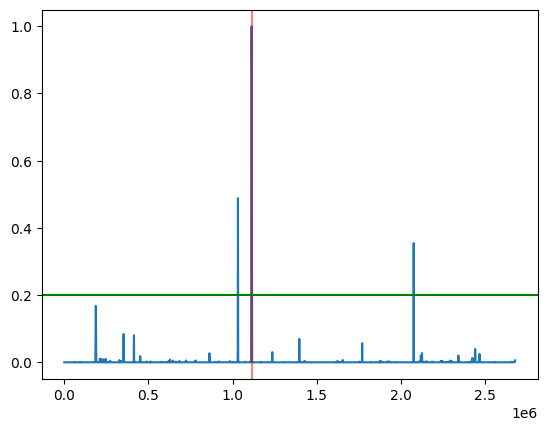

In [26]:
f = FastA("../../data/Fasta/TriTrypDB-68_LmajorFriedlin_Genome.fasta")
#f = FastA("../../data/Fasta/genome.fasta")
#f = FastA("../../data/Fasta/genomes/Lmexicana/ragtag.scaffold.fasta")

#centromeres = pd.read_csv("../../output/estimation/donovani/donovani_genome.csv")
#centromeres = pd.read_csv("../../output/estimation/mexicana.csv")

#f = FastA("../../data/Fasta/genomes/Lmartiniquensis/ragtag.scaffold.fasta")
#centromeres = pd.read_csv("../../output/estimation/martiniquensis.csv")
centromeres = pd.read_csv("../../output/estimation/major/Major.csv")

centromeres = {
    str(row['Chromosome']): (row['start'], row['end'])
    for _, row in centromeres.iterrows()
}

for chrom in range(1,37):
    #f = FastA("LmajorFriedlin/LmajorFriedlin_genome.fasta")
            
    try:
        #seq = f.sequences[chrom-1]
        seq = f.sequences[f.names.index(str(chrom))]

    except:
        seq = f.sequences[chrom-1].upper().replace('N', 'T')
    clf()
    positions, scores = predict_sliding_windows(seq, model)
    _ = plot([x[0] for x in positions], scores)
    start, stop = centromeres[str(chrom)]
    axvline(start, color='r', alpha=0.5)
    axhline(0.2, color='g')
    savefig(f"./all/major/CNN1_{chrom}_Lmajor.png")
    print(chrom, positions[argmax(scores)], max(scores))
    all_scores[chrom] = max(scores)

  0%|                                           | 1/492 [00:00<00:52,  9.42it/s]

ERROR! Session/line number was not unique in database. History logging moved to new session 306


100%|█████████████████████████████████████████| 492/492 [00:41<00:00, 11.80it/s]


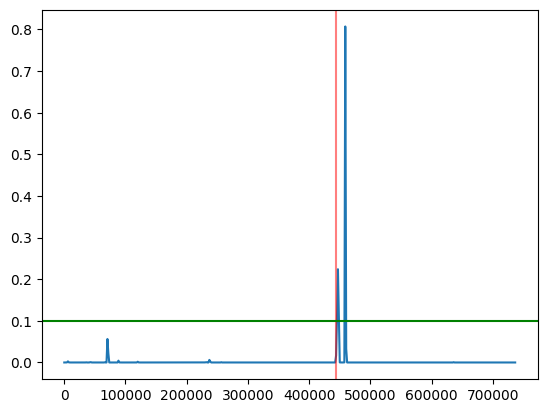

In [20]:
f = FastA("../../data/Fasta/TriTrypDB-68_LmajorFriedlin_Genome.fasta")

recherche = 18
for chrom in range(recherche,recherche+1):
    #f = FastA("LmajorFriedlin/LmajorFriedlin_genome.fasta")
            
    try:
        seq = f.sequences[chrom-1]
    except:
        seq = f.sequences[chrom-1].upper().replace('N', 'T')
    clf()
    positions, scores = predict_sliding_windows(seq, model)
    _ = plot([x[0] for x in positions], scores)
    start, stop = centromeres[str(chrom)]
    axvline(start, color='r', alpha=0.5)
    axhline(0.1, color='g')


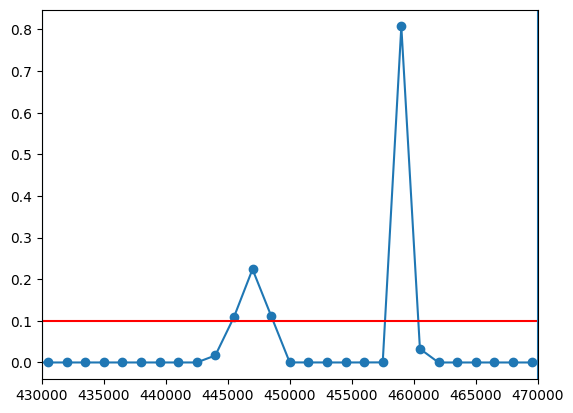

In [23]:
plot([x[0] for  x in positions], scores, 'o-')
xlim([430000,470000])
axhline(0.1, color='r')
axvline(430000)
axvline(470000)

100%|███████████████████████████████████████████| 75/75 [00:06<00:00, 11.99it/s]


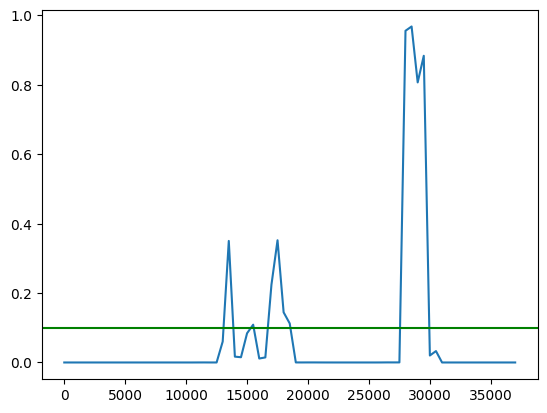

In [26]:
f = FastA("../../data/Fasta/TriTrypDB-68_LmajorFriedlin_Genome.fasta")

recherche = 18
for chrom in range(recherche,recherche+1):
    #f = FastA("LmajorFriedlin/LmajorFriedlin_genome.fasta")
            
    try:
        seq = f.sequences[chrom-1]
    except:
        seq = f.sequences[chrom-1].upper().replace('N', 'T')
    clf()
    seq = seq[430000:470000]
    positions, scores = predict_sliding_windows(seq, model,SIZE,500)
    _ = plot([x[0] for x in positions], scores)
    axhline(0.1, color='g')

100%|█████████████████████████████████████████| 257/257 [00:21<00:00, 12.09it/s]


1 (273000, 276000) 0.4643575


100%|█████████████████████████████████████████| 271/271 [00:21<00:00, 12.50it/s]


2 (289500, 292500) 0.99801993


100%|█████████████████████████████████████████| 276/276 [00:25<00:00, 10.99it/s]


...

34 (336000, 339000) 0.9997866


100%|███████████████████████████████████████| 1451/1451 [02:03<00:00, 11.73it/s]


35 (618000, 621000) 0.9948


100%|███████████████████████████████████████| 1896/1896 [02:40<00:00, 11.80it/s]


36 (1210500, 1213500) 0.90895367


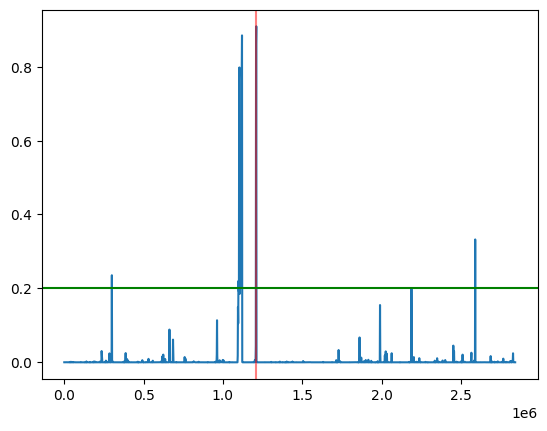

In [27]:
f = FastA("../../data/Fasta/genome.fasta")
#f = FastA("../../data/Fasta/genomes/Lmexicana/ragtag.scaffold.fasta")

centromeres = pd.read_csv("../../output/estimation/donovani/donovani_genome.csv")
#centromeres = pd.read_csv("../../output/estimation/mexicana.csv")

#f = FastA("../../data/Fasta/genomes/Lmartiniquensis/ragtag.scaffold.fasta")
#centromeres = pd.read_csv("../../output/estimation/martiniquensis.csv")

centromeres = {
    str(row['Chromosome']): (row['start'], row['end'])
    for _, row in centromeres.iterrows()
}

for chrom in range(1,37):
    #f = FastA("LmajorFriedlin/LmajorFriedlin_genome.fasta")
            
    try:
        #seq = f.sequences[chrom-1]
        seq = f.sequences[f.names.index(str(chrom))]

    except:
        seq = f.sequences[chrom-1].upper().replace('N', 'T')
    clf()
    positions, scores = predict_sliding_windows(seq, model)
    _ = plot([x[0] for x in positions], scores)
    start, stop = centromeres[str(chrom)]
    axvline(start, color='r', alpha=0.5)
    axhline(0.2, color='g')
    savefig(f"./all/donovani/CNN1_{chrom}_Ldono.png")
    print(chrom, positions[argmax(scores)], max(scores))
    all_scores[chrom] = max(scores)

100%|█████████████████████████████████████████| 181/181 [00:15<00:00, 11.55it/s]


1 (256500, 259500) 0.9695454


100%|█████████████████████████████████████████| 197/197 [00:17<00:00, 11.20it/s]


2 (232500, 235500) 0.9985861


100%|█████████████████████████████████████████| 249/249 [00:22<00:00, 10.98it/s]


...

34 (304500, 307500) 0.99983895


100%|███████████████████████████████████████| 1311/1311 [02:02<00:00, 10.74it/s]


35 (462000, 465000) 0.9879946


100%|███████████████████████████████████████| 2227/2227 [03:25<00:00, 10.85it/s]


36 (3132000, 3135000) 0.9634036


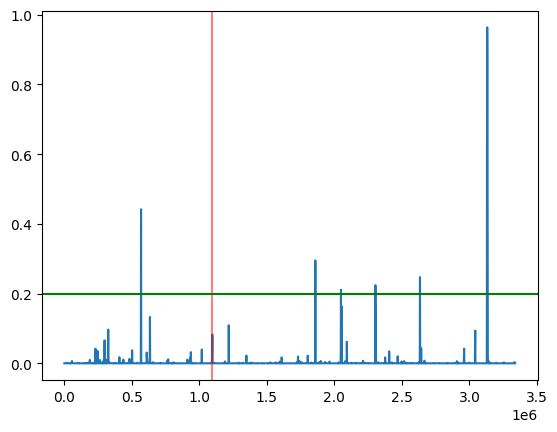

In [29]:

f = FastA("../../data/Fasta/genomes/Lmexicana/ragtag.scaffold.fasta")

#centromeres = pd.read_csv("../../output/estimation/donovani/donovani_genome.csv")
centromeres = pd.read_csv("../../output/estimation/mexicana.csv")

#f = FastA("../../data/Fasta/genomes/Lmartiniquensis/ragtag.scaffold.fasta")
#centromeres = pd.read_csv("../../output/estimation/martiniquensis.csv")

centromeres = {
    str(row['Chromosome']): (row['start'], row['end'])
    for _, row in centromeres.iterrows()
}

for chrom in range(1,37):
    #f = FastA("LmajorFriedlin/LmajorFriedlin_genome.fasta")
            
    try:
        #seq = f.sequences[chrom-1]
        seq = f.sequences[f.names.index(str(chrom))]

    except:
        seq = f.sequences[chrom-1].upper().replace('N', 'T')
    clf()
    positions, scores = predict_sliding_windows(seq, model)
    _ = plot([x[0] for x in positions], scores)
    start, stop = centromeres[str(chrom)]
    axvline(start, color='r', alpha=0.5)
    axhline(0.2, color='g')
    savefig(f"./all/mexicana/CNN1_{chrom}_Lmexicana.png")
    print(chrom, positions[argmax(scores)], max(scores))
    all_scores[chrom] = max(scores)

100%|█████████████████████████████████████████| 160/160 [00:13<00:00, 11.76it/s]


1 (1500, 4500) 0.010162301


100%|█████████████████████████████████████████| 246/246 [00:20<00:00, 11.95it/s]


2 (279000, 282000) 0.9808133


100%|█████████████████████████████████████████| 256/256 [00:21<00:00, 12.06it/s]


...

34 (322500, 325500) 0.9565512


100%|███████████████████████████████████████| 1368/1368 [02:00<00:00, 11.35it/s]


35 (504000, 507000) 0.71166164


100%|███████████████████████████████████████| 1804/1804 [02:40<00:00, 11.22it/s]


36 (1152000, 1155000) 0.8853949


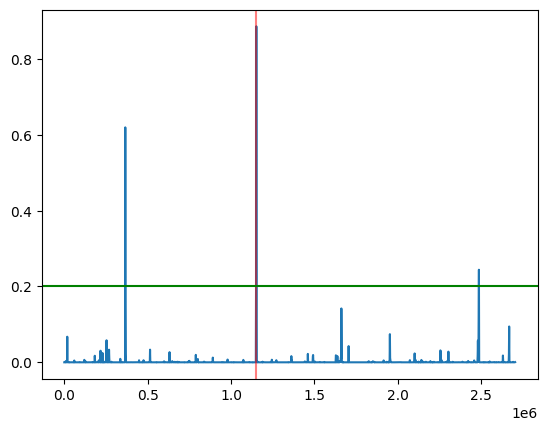

In [28]:



f = FastA("../../data/Fasta/genomes/Lmartiniquensis/ragtag.scaffold.fasta")
centromeres = pd.read_csv("../../output/estimation/martiniquensis.csv")

centromeres = {
    str(row['Chromosome']): (row['start'], row['end'])
    for _, row in centromeres.iterrows()
}

for chrom in range(1,37):
    #f = FastA("LmajorFriedlin/LmajorFriedlin_genome.fasta")
            
    try:
        #seq = f.sequences[chrom-1]
        seq = f.sequences[f.names.index(str(chrom))]

    except:
        seq = f.sequences[chrom-1].upper().replace('N', 'T')
    clf()
    positions, scores = predict_sliding_windows(seq, model)
    _ = plot([x[0] for x in positions], scores)
    start, stop = centromeres[str(chrom)]
    axvline(start, color='r', alpha=0.5)
    axhline(0.2, color='g')
    savefig(f"./all/martiniquensis/CNN1_{chrom}_Lmarti.png")
    print(chrom, positions[argmax(scores)], max(scores))
    all_scores[chrom] = max(scores)